# EfficientDet 기반 제조 영상 분석 최적화

## 프로젝트 목표

이번 프로젝트에서는 EfficientDet-D0의 구조와 추론 과정을 확인하고 Custom Dataset을 이용해 직접 학습과 평가를 진행했습니다.

교안의 기본 실습에서 더 나아가 데이터셋의 특징을 직접 확인하고, 두 종류의 실제 영상을 이용해 EfficientDet의 영상 처리 성능도 확인했습니다.

또 같은 영상에서 YOLOv8n도 실행해 Model FPS, End-to-End FPS, P95 Latency 등을 비교하면서 모델 자체의 추론 속도와 실제 영상 시스템의 처리속도가 얼마나 다를 수 있는지도 살펴봤습니다.

최종적으로 어떤 모델이 무조건 더 좋다고 결론내리기보다는 같은 환경에서 직접 실행해보고 각 모델의 특성과 실제 사용 조건에 따른 차이를 확인하는 것을 목표로 진행했습니다.

## AI 도구 활용

Python 코드 작성과 환경 설정, 오류를 해결하는 과정에서 ChatGPT를 보조 도구로 활용했습니다.

생성된 코드를 그대로 사용하는 것보다는 각 코드가 어떤 역할을 하는지 확인하고 직접 실행한 결과를 비교하면서 실험 조건과 결과를 정리했습니다.

특히 데이터 특성 분석, 영상 테스트, EfficientDet과 YOLO의 속도 비교는 교안의 기본 실습에서 추가하여 진행했습니다.


In [1]:
import os
from pathlib import Path

REPO_DIR = Path(
    r"C:\Users\USER\Desktop\ERICA_X_MODULABS_CV\05_EfficientDet\Yet-Another-EfficientDet-Pytorch"
)

assert REPO_DIR.exists(), f"저장소를 찾을 수 없음: {REPO_DIR}"
assert (REPO_DIR / "train.py").exists(), "train.py가 없습니다."

os.chdir(REPO_DIR)

print("현재 작업 위치:", Path.cwd())

현재 작업 위치: C:\Users\USER\Desktop\ERICA_X_MODULABS_CV\05_EfficientDet\Yet-Another-EfficientDet-Pytorch


In [2]:
from pathlib import Path

DESKTOP = Path(r"C:\Users\USER\Desktop")

candidates = list(
    DESKTOP.rglob("Vehicles_Detection.v8i.coco")
)

print("찾은 후보:")
for p in candidates:
    print(p)

SRC_ROOT = next(
    p for p in candidates
    if "No_Apply_Grayscale" in str(p)
)

print("\n사용할 데이터셋:")
print(SRC_ROOT)

찾은 후보:
C:\Users\USER\Desktop\archive\No_Apply_Grayscale\No_Apply_Grayscale\Vehicles_Detection.v8i.coco

사용할 데이터셋:
C:\Users\USER\Desktop\archive\No_Apply_Grayscale\No_Apply_Grayscale\Vehicles_Detection.v8i.coco


In [3]:
import json

for split in ["train", "valid", "test"]:
    split_dir = SRC_ROOT / split
    json_path = split_dir / "_annotations.coco.json"

    with open(json_path, "r", encoding="utf-8") as f:
        coco = json.load(f)

    images = list(split_dir.glob("*.jpg"))

    print(
        split,
        "| images:", len(images),
        "| annotations:", len(coco["annotations"])
    )

print("\nCategories:")
print(coco["categories"])

train | images: 102 | annotations: 2069
valid | images: 28 | annotations: 563
test | images: 13 | annotations: 254

Categories:
[{'id': 0, 'name': 'cars', 'supercategory': 'none'}, {'id': 1, 'name': 'Bus', 'supercategory': 'cars'}, {'id': 2, 'name': 'Car', 'supercategory': 'cars'}, {'id': 3, 'name': 'Motorcycle', 'supercategory': 'cars'}, {'id': 4, 'name': 'Pickup', 'supercategory': 'cars'}, {'id': 5, 'name': 'Truck', 'supercategory': 'cars'}]


In [2]:
from pathlib import Path
import os
import json

# EfficientDet repository
REPO_DIR = Path(
    r"C:\Users\USER\Desktop\ERICA_X_MODULABS_CV\05_EfficientDet\Yet-Another-EfficientDet-Pytorch"
)

# 바탕화면
DESKTOP = Path(r"C:\Users\USER\Desktop")

# 바탕화면 아래에서 실제 데이터셋 자동 검색
candidates = list(
    DESKTOP.rglob("Vehicles_Detection.v8i.coco")
)

print("검색된 v8i 데이터셋:")
for p in candidates:
    print(" -", p)

# No_Apply_Grayscale 버전만 선택
matches = [
    p for p in candidates
    if "No_Apply_Grayscale" in str(p)
]

assert len(matches) > 0, (
    "No_Apply_Grayscale/Vehicles_Detection.v8i.coco 폴더를 "
    "바탕화면에서 찾지 못했습니다."
)

SRC_ROOT = matches[0]

# EfficientDet 학습용으로 만들 최종 폴더
PROJECT_NAME = "my_car_detect_proj"
DST_ROOT = REPO_DIR / "datasets" / PROJECT_NAME
ANNOT_DIR = DST_ROOT / "annotations"

# train.py를 상대경로로 실행하기 위해 repository로 이동
os.chdir(REPO_DIR)

print("\n사용할 데이터셋:")
print(SRC_ROOT)

print("\nEfficientDet repository:")
print(Path.cwd())

# 데이터가 실제로 있는지 확인
for split in ["train", "valid", "test"]:
    split_dir = SRC_ROOT / split
    annotation_file = split_dir / "_annotations.coco.json"

    print(
        split,
        "| folder:", split_dir.exists(),
        "| annotation:", annotation_file.exists()
    )

검색된 v8i 데이터셋:
 - C:\Users\USER\Desktop\archive\No_Apply_Grayscale\No_Apply_Grayscale\Vehicles_Detection.v8i.coco

사용할 데이터셋:
C:\Users\USER\Desktop\archive\No_Apply_Grayscale\No_Apply_Grayscale\Vehicles_Detection.v8i.coco

EfficientDet repository:
C:\Users\USER\Desktop\ERICA_X_MODULABS_CV\05_EfficientDet\Yet-Another-EfficientDet-Pytorch
train | folder: True | annotation: True
valid | folder: True | annotation: True
test | folder: True | annotation: True


In [3]:
import cv2
import numpy as np
from tqdm import tqdm

train_images = sorted((SRC_ROOT / "train").glob("*.jpg"))

assert len(train_images) > 0, "Train 이미지를 찾지 못했습니다."

print("Train image count:", len(train_images))

means = []
stds = []

for path in tqdm(train_images):
    img = cv2.imread(str(path))

    if img is None:
        print("읽기 실패:", path)
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img.astype(np.float32) / 255.0

    means.append(img.mean(axis=(0, 1)))
    stds.append(img.std(axis=(0, 1)))

mean = np.mean(means, axis=0)
std = np.mean(stds, axis=0)

print("RGB mean:", mean.tolist())
print("RGB std :", std.tolist())

Train image count: 102


100%|██████████| 102/102 [00:07<00:00, 12.91it/s]

RGB mean: [0.46414491534233093, 0.47258609533309937, 0.4702204465866089]
RGB std : [0.16531963646411896, 0.164224311709404, 0.16307924687862396]


## 데이터셋 구성 확인

이번 실습에서는 차량 객체 탐지 데이터를 사용했습니다.

학습을 시작하기 전에 Train, Validation, Test 데이터가 실제로 몇 장씩 있는지 확인하고 COCO Annotation의 객체 수도 함께 확인했습니다.

확인 결과 Train 102장, Validation 28장, Test 13장으로 구성되어 있었으며 Train에는 2069개의 Annotation이 포함되어 있었습니다.

단순히 모델부터 학습하기보다 데이터가 어떤 형태로 구성되어 있는지 먼저 확인하고 이후 학습 결과를 해석하려고 했습니다.


In [4]:
train_json = SRC_ROOT / "train" / "_annotations.coco.json"

with open(train_json, "r", encoding="utf-8") as f:
    coco_train = json.load(f)

ratios = []
scales = []

for ann in coco_train["annotations"]:
    x, y, w, h = ann["bbox"]

    if w > 0 and h > 0:
        ratios.append(w / h)
        scales.append(np.sqrt(w * h))

ratios = np.array(ratios)
scales = np.array(scales)

ratio_p = np.percentile(ratios, [20, 50, 80])
scale_p = np.percentile(scales, [20, 50, 80])

# 중앙값을 1로 정규화
scale_norm = scale_p / scale_p[1]

print("Annotation count:", len(ratios))
print("Anchor ratio :", np.round(ratio_p, 2))
print("Anchor scale :", np.round(scale_norm, 2))

Annotation count: 2069
Anchor ratio : [0.52 0.67 0.82]
Anchor scale : [0.54 1.   2.13]


In [ ]:
from pathlib import Path
from collections import Counter
import json
import numpy as np
import matplotlib.pyplot as plt

SRC_ROOT_ANALYSIS = Path(
    r'C:\Users\USER\Desktop\archive\No_Apply_Grayscale\No_Apply_Grayscale\Vehicles_Detection.v8i.coco'
)

TRAIN_JSON_ANALYSIS = (
    SRC_ROOT_ANALYSIS
    / 'train'
    / '_annotations.coco.json'
)

with open(
    TRAIN_JSON_ANALYSIS,
    'r',
    encoding='utf-8'
) as f:
    coco_analysis = json.load(f)

category_names = {
    c['id']: c['name']
    for c in coco_analysis['categories']
}

image_info = {
    img['id']: img
    for img in coco_analysis['images']
}

class_counts = Counter()
aspect_ratios = []
normalized_areas = []

for ann in coco_analysis['annotations']:

    class_counts[ann['category_id']] += 1

    x, y, w, h = ann['bbox']

    if w > 0 and h > 0:

        aspect_ratios.append(
            w / h
        )

        img = image_info[ann['image_id']]

        image_area = (
            img['width']
            * img['height']
        )

        normalized_areas.append(
            (w * h)
            / image_area
        )


print('[클래스별 객체 수]')

for class_id in sorted(class_counts):

    print(
        f'{category_names[class_id]:>12} : '
        f'{class_counts[class_id]}'
    )


labels = [
    category_names[i]
    for i in sorted(class_counts)
]

counts = [
    class_counts[i]
    for i in sorted(class_counts)
]

plt.figure(figsize=(7, 4))
plt.bar(labels, counts)
plt.title('Train Dataset Class Distribution')
plt.ylabel('Number of Objects')
plt.xticks(rotation=30)
plt.show()


plt.figure(figsize=(7, 4))
plt.hist(
    aspect_ratios,
    bins=30
)
plt.title('Bounding Box Aspect Ratio Distribution')
plt.xlabel('width / height')
plt.ylabel('Count')
plt.show()


plt.figure(figsize=(7, 4))
plt.hist(
    normalized_areas,
    bins=30
)
plt.title('Normalized Bounding Box Area Distribution')
plt.xlabel('bbox area / image area')
plt.ylabel('Count')
plt.show()


### 데이터 특성을 추가로 확인한 이유

EfficientDet은 Anchor를 기준으로 객체 위치와 크기를 예측하기 때문에 학습 데이터에 어떤 크기와 비율의 객체가 많이 포함되어 있는지 확인하는 것이 의미가 있다고 생각했습니다.

그래서 기본 실습에 추가로 클래스별 객체 수와 Bounding Box의 종횡비, 이미지 대비 객체 크기 분포를 확인했습니다.

이 결과는 이후 직접 계산한 Anchor Ratio와 Anchor Scale 값을 이해하는 데 참고했습니다.


## 데이터셋에 맞춘 전처리 값과 Anchor 설정

교안의 기본 설정을 그대로 사용하는 대신 이번 데이터셋의 Train 이미지에서 RGB Mean과 Standard Deviation을 직접 계산했습니다.

또 COCO Annotation의 Bounding Box 크기와 비율을 이용해 데이터셋에서 자주 나타나는 객체 형태를 확인하고 Anchor Ratio와 Anchor Scale 후보를 계산했습니다.

현재 데이터에서는 RGB Mean이 약 `[0.464, 0.473, 0.470]`, Standard Deviation이 약 `[0.165, 0.164, 0.163]`으로 계산되었습니다.

Anchor Ratio는 약 `[0.52, 0.67, 0.82]`, 정규화한 Anchor Scale은 약 `[0.54, 1.00, 2.13]`으로 확인되었습니다.

이 값들이 기본 Anchor보다 성능을 높였다고 바로 결론내릴 수는 없지만, 모델 설정을 데이터 특성에 맞춰 직접 구성해보는 과정으로 진행했습니다.


In [5]:
import shutil
import copy
import json

PROJECT_NAME = "my_car_detect_proj"

DST_ROOT = REPO_DIR / "datasets" / PROJECT_NAME
ANNOT_DIR = DST_ROOT / "annotations"

SPLITS = ["train", "valid", "test"]

for split in SPLITS:
    (DST_ROOT / split).mkdir(parents=True, exist_ok=True)

ANNOT_DIR.mkdir(parents=True, exist_ok=True)

for split in SPLITS:
    src_split = SRC_ROOT / split
    dst_split = DST_ROOT / split

    # 이미지 복사
    for img_path in src_split.glob("*.jpg"):
        shutil.copy2(img_path, dst_split / img_path.name)

    # COCO annotation 읽기
    json_path = src_split / "_annotations.coco.json"

    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    converted = copy.deepcopy(data)

    # EfficientDet repo가 1-indexed category_id를 요구하므로 +1
    for category in converted["categories"]:
        category["id"] += 1

    for annotation in converted["annotations"]:
        annotation["category_id"] += 1

        if "ignore" not in annotation:
            annotation["ignore"] = 0

    dst_json = ANNOT_DIR / f"instances_{split}.json"

    with open(dst_json, "w", encoding="utf-8") as f:
        json.dump(converted, f, indent=2)

    print(
        split,
        "| images:", len(list(dst_split.glob("*.jpg"))),
        "| annotation:", dst_json.name
    )

train | images: 102 | annotation: instances_train.json
valid | images: 28 | annotation: instances_valid.json
test | images: 13 | annotation: instances_test.json


## COCO 데이터 형식 변환

원본 데이터는 COCO 형식이지만 현재 EfficientDet Repository의 학습 코드에서 사용할 수 있도록 폴더 구조와 Annotation 파일 이름을 다시 구성했습니다.

또 Repository에서 사용하는 Category ID 형식에 맞추기 위해 기존 0부터 시작하던 Category ID를 1부터 시작하도록 변환했습니다.

이 과정을 통해 같은 COCO 형식이라도 사용하는 Framework나 Repository에 따라 데이터 구조를 맞춰주는 과정이 필요하다는 점을 확인했습니다.


In [6]:
with open(
    ANNOT_DIR / "instances_train.json",
    "r",
    encoding="utf-8"
) as f:
    check = json.load(f)

print(check["categories"])

[{'id': 1, 'name': 'cars', 'supercategory': 'none'}, {'id': 2, 'name': 'Bus', 'supercategory': 'cars'}, {'id': 3, 'name': 'Car', 'supercategory': 'cars'}, {'id': 4, 'name': 'Motorcycle', 'supercategory': 'cars'}, {'id': 5, 'name': 'Pickup', 'supercategory': 'cars'}, {'id': 6, 'name': 'Truck', 'supercategory': 'cars'}]


In [7]:
import yaml

obj_list = [
    cat["name"]
    for cat in sorted(
        check["categories"],
        key=lambda x: x["id"]
    )
]

config = {
    "project_name": PROJECT_NAME,
    "train_set": "train",
    "val_set": "valid",

    # 중요: 0은 CPU이므로 GPU 1개 사용 시 1
    "num_gpus": 1,

    "mean": [float(x) for x in mean],
    "std": [float(x) for x in std],

    "anchors_scales": str(
        [round(float(x), 2) for x in scale_norm]
    ),

    "anchors_ratios": str(
        [
            (round(float(r), 2), 1.0)
            for r in ratio_p
        ]
    ),

    "obj_list": obj_list
}

PROJECT_YAML = REPO_DIR / "projects" / f"{PROJECT_NAME}.yml"

with open(PROJECT_YAML, "w", encoding="utf-8") as f:
    yaml.safe_dump(
        config,
        f,
        sort_keys=False,
        allow_unicode=True
    )

print(PROJECT_YAML)

with open(PROJECT_YAML, "r", encoding="utf-8") as f:
    print(f.read())

C:\Users\USER\Desktop\ERICA_X_MODULABS_CV\05_EfficientDet\Yet-Another-EfficientDet-Pytorch\projects\my_car_detect_proj.yml
project_name: my_car_detect_proj
train_set: train
val_set: valid
num_gpus: 1
mean:
- 0.46414491534233093
- 0.47258609533309937
- 0.4702204465866089
std:
- 0.16531963646411896
- 0.164224311709404
- 0.16307924687862396
anchors_scales: '[0.54, 1.0, 2.13]'
anchors_ratios: '[(0.52, 1.0), (0.67, 1.0), (0.82, 1.0)]'
obj_list:
- cars
- Bus
- Car
- Motorcycle
- Pickup
- Truck



In [8]:
TRAIN_PY = REPO_DIR / "train.py"

text = TRAIN_PY.read_text(encoding="utf-8")

old = "torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, verbose=True)"
new = "torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3)"

if old in text:
    text = text.replace(old, new)
    TRAIN_PY.write_text(text, encoding="utf-8")
    print("train.py scheduler 수정 완료")
else:
    print("이미 수정되었거나 해당 코드가 없음")

train.py scheduler 수정 완료


In [9]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.14.0+cu130
True
NVIDIA GeForce RTX 4050 Laptop GPU


## 실습 환경 확인

이전 YOLO 실습과 마찬가지로 EfficientDet에서도 GPU 환경이 제대로 연결되어 있는지 먼저 확인했습니다.

현재 실습에서는 CV conda 환경을 사용했고 PyTorch에서 CUDA 사용 가능 여부가 True로 확인되었습니다.

GPU는 NVIDIA GeForce RTX 4050 Laptop GPU를 사용했습니다.

EfficientDet 학습과 영상 추론의 처리속도는 사용하는 GPU와 실행 환경에 영향을 받기 때문에 이후 FPS 결과도 현재 환경을 기준으로 해석했습니다.


In [10]:
import sys
import subprocess
import time

head_start = time.time()

cmd = [
    sys.executable,
    "train.py",
    "-c", "0",
    "-p", PROJECT_NAME,
    "-n", "0",
    "--head_only", "True",
    "--lr", "1e-3",
    "--batch_size", "4",
    "--load_weights", "weights/efficientdet-d0.pth",
    "--num_epochs", "10",
    "--save_interval", "100"
]

print("실행 명령:")
print(" ".join(cmd))

subprocess.run(cmd, check=True)

실행 명령:
C:\Users\USER\.conda\envs\cv\python.exe train.py -c 0 -p my_car_detect_proj -n 0 --head_only True --lr 1e-3 --batch_size 4 --load_weights weights/efficientdet-d0.pth --num_epochs 10 --save_interval 100


CompletedProcess(args=['C:\\Users\\USER\\.conda\\envs\\cv\\python.exe', 'train.py', '-c', '0', '-p', 'my_car_detect_proj', '-n', '0', '--head_only', 'True', '--lr', '1e-3', '--batch_size', '4', '--load_weights', 'weights/efficientdet-d0.pth', '--num_epochs', '10', '--save_interval', '100'], returncode=0)

## 1단계 - Detection Head 우선 학습

먼저 사전학습된 EfficientDet-D0의 특징 추출 부분은 최대한 유지하고 Detection Head를 우선 10 Epoch 학습했습니다.

처음부터 모델 전체를 크게 변경하기보다는 기존에 학습된 특징을 활용하면서 현재 차량 데이터셋의 클래스와 Bounding Box 예측 부분을 먼저 맞추기 위한 과정으로 이해했습니다.

Head 학습이 끝난 뒤 생성된 Checkpoint를 다음 Fine Tuning 단계의 초기 Weight로 사용했습니다.


In [11]:
LOG_DIR = REPO_DIR / "logs" / PROJECT_NAME

head_ckpts = [
    p for p in LOG_DIR.glob("*.pth")
    if p.stat().st_mtime >= head_start - 2
]

assert head_ckpts, "Head 학습 checkpoint를 찾지 못했습니다."

HEAD_CKPT = max(
    head_ckpts,
    key=lambda p: p.stat().st_mtime
)

print("Head checkpoint:")
print(HEAD_CKPT)

Head checkpoint:
C:\Users\USER\Desktop\ERICA_X_MODULABS_CV\05_EfficientDet\Yet-Another-EfficientDet-Pytorch\logs\my_car_detect_proj\efficientdet-d0_9_250.pth


In [12]:
full_start = time.time()

cmd = [
    sys.executable,
    "train.py",
    "-c", "0",
    "-p", PROJECT_NAME,
    "-n", "0",
    "--head_only", "False",
    "--lr", "1e-3",
    "--batch_size", "4",
    "--load_weights", str(HEAD_CKPT),
    "--num_epochs", "30",
    "--save_interval", "100"
]

print("실행 명령:")
print(" ".join(cmd))

subprocess.run(cmd, check=True)

실행 명령:
C:\Users\USER\.conda\envs\cv\python.exe train.py -c 0 -p my_car_detect_proj -n 0 --head_only False --lr 1e-3 --batch_size 4 --load_weights C:\Users\USER\Desktop\ERICA_X_MODULABS_CV\05_EfficientDet\Yet-Another-EfficientDet-Pytorch\logs\my_car_detect_proj\efficientdet-d0_9_250.pth --num_epochs 30 --save_interval 100


CompletedProcess(args=['C:\\Users\\USER\\.conda\\envs\\cv\\python.exe', 'train.py', '-c', '0', '-p', 'my_car_detect_proj', '-n', '0', '--head_only', 'False', '--lr', '1e-3', '--batch_size', '4', '--load_weights', 'C:\\Users\\USER\\Desktop\\ERICA_X_MODULABS_CV\\05_EfficientDet\\Yet-Another-EfficientDet-Pytorch\\logs\\my_car_detect_proj\\efficientdet-d0_9_250.pth', '--num_epochs', '30', '--save_interval', '100'], returncode=0)

## 2단계 - 전체 모델 Fine Tuning

Head 학습에서 생성된 Checkpoint를 이용해 이번에는 `head_only=False`로 설정하고 전체 모델을 추가로 학습했습니다.

총 30 Epoch 조건으로 Fine Tuning을 진행했으며 최종적으로 `efficientdet-d0_27_700.pth` Checkpoint를 평가에 사용했습니다.

이 과정을 통해 사전학습 모델을 새로운 Dataset에 적용할 때 Head만 먼저 학습한 뒤 전체 모델을 조정하는 과정을 직접 확인할 수 있었습니다.


In [13]:
full_ckpts = [
    p for p in LOG_DIR.glob("*.pth")
    if p.stat().st_mtime >= full_start - 2
]

assert full_ckpts, "Fine-tuning checkpoint를 찾지 못했습니다."

FINAL_CKPT = max(
    full_ckpts,
    key=lambda p: p.stat().st_mtime
)

print("최종 checkpoint:")
print(FINAL_CKPT)

최종 checkpoint:
C:\Users\USER\Desktop\ERICA_X_MODULABS_CV\05_EfficientDet\Yet-Another-EfficientDet-Pytorch\logs\my_car_detect_proj\efficientdet-d0_27_700.pth


In [14]:
cmd = [
    sys.executable,
    "coco_eval.py",
    "-c", "0",
    "-p", PROJECT_NAME,
    "-w", str(FINAL_CKPT)
]

subprocess.run(cmd, check=True)

CompletedProcess(args=['C:\\Users\\USER\\.conda\\envs\\cv\\python.exe', 'coco_eval.py', '-c', '0', '-p', 'my_car_detect_proj', '-w', 'C:\\Users\\USER\\Desktop\\ERICA_X_MODULABS_CV\\05_EfficientDet\\Yet-Another-EfficientDet-Pytorch\\logs\\my_car_detect_proj\\efficientdet-d0_27_700.pth'], returncode=0)

In [15]:
from pathlib import Path

pred_file = REPO_DIR / "valid_bbox_results.json"

print("예측 결과 파일 존재:", pred_file.exists())
print("파일 위치:", pred_file)

if pred_file.exists():
    print("파일 크기:", pred_file.stat().st_size, "bytes")

예측 결과 파일 존재: True
파일 위치: C:\Users\USER\Desktop\ERICA_X_MODULABS_CV\05_EfficientDet\Yet-Another-EfficientDet-Pytorch\valid_bbox_results.json
파일 크기: 4014519 bytes


In [16]:
import yaml
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# 프로젝트 설정 읽기
with open(PROJECT_YAML, "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

val_set = cfg["val_set"]

# Ground Truth
gt_path = (
    REPO_DIR
    / "datasets"
    / PROJECT_NAME
    / "annotations"
    / f"instances_{val_set}.json"
)

# EfficientDet이 생성한 Prediction
pred_path = REPO_DIR / f"{val_set}_bbox_results.json"

print("GT 존재:", gt_path.exists())
print("Prediction 존재:", pred_path.exists())
print("GT:", gt_path)
print("Prediction:", pred_path)

GT 존재: True
Prediction 존재: True
GT: C:\Users\USER\Desktop\ERICA_X_MODULABS_CV\05_EfficientDet\Yet-Another-EfficientDet-Pytorch\datasets\my_car_detect_proj\annotations\instances_valid.json
Prediction: C:\Users\USER\Desktop\ERICA_X_MODULABS_CV\05_EfficientDet\Yet-Another-EfficientDet-Pytorch\valid_bbox_results.json


In [17]:
# COCO Ground Truth 로드
coco_gt = COCO(str(gt_path))

# 모델 예측 결과 로드
coco_pred = coco_gt.loadRes(str(pred_path))

# COCO Detection 평가
coco_eval = COCOeval(
    coco_gt,
    coco_pred,
    "bbox"
)

coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.15s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=1.35s).
Accumulating evaluation results...
DONE (t=0.14s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.123
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.252
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.082
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.083
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.234
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.271
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.117
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.221
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

In [18]:
print(f"mAP@0.5:0.95 : {coco_eval.stats[0]:.4f}")
print(f"mAP@0.5      : {coco_eval.stats[1]:.4f}")
print(f"mAP@0.75     : {coco_eval.stats[2]:.4f}")

print(f"AP Small      : {coco_eval.stats[3]:.4f}")
print(f"AP Medium     : {coco_eval.stats[4]:.4f}")
print(f"AP Large      : {coco_eval.stats[5]:.4f}")

print(f"AR@100        : {coco_eval.stats[8]:.4f}")

mAP@0.5:0.95 : 0.1233
mAP@0.5      : 0.2515
mAP@0.75     : 0.0817
AP Small      : 0.0832
AP Medium     : 0.2340
AP Large      : 0.2712
AR@100        : 0.2683


## COCO 평가 결과 해석

최종 Checkpoint를 Validation Dataset으로 평가한 결과 mAP@0.5:0.95는 약 0.123, mAP@0.5는 약 0.252로 확인되었습니다.

객체 크기별 AP를 확인하면 Small은 약 0.083, Medium은 약 0.234, Large는 약 0.271로 나타났습니다.

현재 결과에서는 큰 객체와 중간 크기 객체에 비해 작은 객체의 AP가 가장 낮게 나타났습니다.

따라서 전체 mAP 하나만 확인하기보다 객체 크기에 따른 탐지 성능 차이도 같이 확인할 필요가 있다고 생각했습니다.

이번 결과는 모델 구조 자체의 성능을 일반화해서 판단하기 위한 값이라기보다 현재 Dataset, 학습 Epoch, Anchor 설정과 학습 조건에서 얻은 결과로 해석했습니다.


In [19]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import yaml

from backbone import EfficientDetBackbone
from efficientdet.utils import BBoxTransform, ClipBoxes
from utils.utils import preprocess, invert_affine, postprocess

with open(PROJECT_YAML, "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

obj_list = cfg["obj_list"]

ratios = eval(cfg["anchors_ratios"])
scales = eval(cfg["anchors_scales"])

test_images = sorted(
    (DST_ROOT / "test").glob("*.jpg")
)

img_path = str(test_images[0])

print("Test image:")
print(img_path)

Test image:
C:\Users\USER\Desktop\ERICA_X_MODULABS_CV\05_EfficientDet\Yet-Another-EfficientDet-Pytorch\datasets\my_car_detect_proj\test\frame_0990_jpg.rf.a3223422e734a57442ee34a58d24d4b4.jpg


In [20]:
compound_coef = 0
input_size = 512

threshold = 0.4
iou_threshold = 0.2

ori_imgs, framed_imgs, framed_metas = preprocess(
    img_path,
    max_size=input_size,
    mean=cfg["mean"],
    std=cfg["std"]
)

x = torch.stack(
    [torch.from_numpy(fi).cuda() for fi in framed_imgs],
    0
)

x = x.float().permute(0, 3, 1, 2)

model_custom = EfficientDetBackbone(
    compound_coef=0,
    num_classes=len(obj_list),
    ratios=ratios,
    scales=scales
)

model_custom.load_state_dict(
    torch.load(
        FINAL_CKPT,
        map_location="cpu"
    )
)

model_custom.requires_grad_(False)
model_custom.eval()
model_custom.cuda()

EfficientDetBackbone(
  (bifpn): Sequential(
    (0): BiFPN(
      (conv6_up): SeparableConvBlock(
        (depthwise_conv): Conv2dStaticSamePadding(
          (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), groups=64, bias=False)
        )
        (pointwise_conv): Conv2dStaticSamePadding(
          (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
        )
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
      )
      (conv5_up): SeparableConvBlock(
        (depthwise_conv): Conv2dStaticSamePadding(
          (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), groups=64, bias=False)
        )
        (pointwise_conv): Conv2dStaticSamePadding(
          (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
        )
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
      )
      (conv4_up): SeparableConvBlock(
        (depthwise_conv): Conv2dSta

In [21]:
regressBoxes = BBoxTransform()
clipBoxes = ClipBoxes()

with torch.no_grad():
    features, regression, classification, anchors = model_custom(x)

    out = postprocess(
        x,
        anchors,
        regression,
        classification,
        regressBoxes,
        clipBoxes,
        threshold,
        iou_threshold
    )

out = invert_affine(framed_metas, out)

print(out)

[{'rois': array([[185.12698 , 323.6734  , 216.37581 , 361.59323 ],
       [ 10.334427, 280.78177 ,  46.4056  , 314.56387 ],
       [275.2236  , 277.61746 , 294.30853 , 312.13898 ]], dtype=float32), 'class_ids': array([2, 2, 2]), 'scores': array([0.4549642 , 0.45462885, 0.41057155], dtype=float32)}]


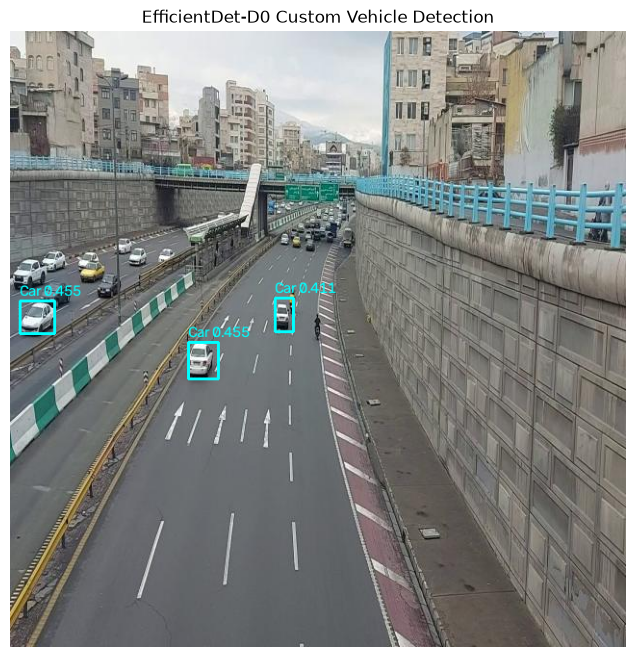

In [22]:
img = ori_imgs[0].copy()

for j in range(len(out[0]["rois"])):
    x1, y1, x2, y2 = out[0]["rois"][j].astype(np.int32)

    class_id = int(out[0]["class_ids"][j])
    score = float(out[0]["scores"][j])

    label = obj_list[class_id]

    cv2.rectangle(
        img,
        (x1, y1),
        (x2, y2),
        (255, 255, 0),
        2
    )

    cv2.putText(
        img,
        f"{label} {score:.3f}",
        (x1, max(15, y1 - 5)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255, 255, 0),
        1
    )

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("EfficientDet-D0 Custom Vehicle Detection")
plt.show()

In [23]:
import time

# GPU warm-up
with torch.no_grad():
    for _ in range(10):
        features, regression, classification, anchors = model_custom(x)

torch.cuda.synchronize()

N = 50
start = time.perf_counter()

with torch.no_grad():
    for _ in range(N):
        features, regression, classification, anchors = model_custom(x)

torch.cuda.synchronize()

elapsed = time.perf_counter() - start

fps = N / elapsed
latency_ms = elapsed / N * 1000

print(f"Inference FPS: {fps:.2f}")
print(f"Inference latency: {latency_ms:.2f} ms/image")

Inference FPS: 8.92
Inference latency: 112.06 ms/image


In [ ]:
#영상 평가

In [24]:
from pathlib import Path

ARCHIVE_DIR = Path(r"C:\Users\USER\Desktop\archive")

VIDEO_PATHS = {
    "Low": ARCHIVE_DIR / "SampleVideo_LowQuality.mp4",
    "High": ARCHIVE_DIR / "Sample_Video_HighQuality.mp4"
}

for name, path in VIDEO_PATHS.items():
    print(name, ":", path.exists(), path)

Low : True C:\Users\USER\Desktop\archive\SampleVideo_LowQuality.mp4
High : True C:\Users\USER\Desktop\archive\Sample_Video_HighQuality.mp4


# 실제 영상 추론 추가 실험

교안에서는 영상도 이미지의 연속이기 때문에 각 Frame에 동일한 객체 탐지 과정을 적용할 수 있다고 설명합니다.

이번에는 여기서 더 나아가 제공된 Low Quality와 High Quality 두 영상을 직접 사용해 EfficientDet-D0의 영상 처리속도를 측정했습니다.

평균 Inference Time뿐 아니라 순간적으로 느려지는 구간도 확인하기 위해 P95 Latency를 계산했고, 모델 내부 추론속도인 Model FPS와 영상 읽기, 전처리, 후처리, 결과 저장까지 포함한 End-to-End FPS를 따로 측정했습니다.


In [25]:
import cv2
import torch
import numpy as np
import time

from collections import Counter
from utils.utils import preprocess_video, postprocess, invert_affine

In [26]:
def run_efficientdet_video(
    video_path,
    output_path,
    model,
    cfg,
    obj_list,
    regressBoxes,
    clipBoxes,
    input_size=512,
    threshold=0.4,
    iou_threshold=0.2
):
    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        raise RuntimeError(f"영상 열기 실패: {video_path}")

    source_fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    writer = cv2.VideoWriter(
        str(output_path),
        cv2.VideoWriter_fourcc(*"mp4v"),
        source_fps,
        (width, height)
    )

    inference_times = []
    confidences = []
    detections_per_frame = []
    class_counter = Counter()

    frame_count = 0
    frames_with_detection = 0

    torch.cuda.synchronize()
    total_start = time.perf_counter()

    while True:
        ret, frame = cap.read()

        if not ret:
            break

        # 1. 전처리
        ori_imgs, framed_imgs, framed_metas = preprocess_video(
            frame,
            max_size=input_size,
            mean=cfg["mean"],
            std=cfg["std"]
        )

        x = torch.stack(
            [torch.from_numpy(fi).cuda() for fi in framed_imgs],
            0
        )

        x = x.float().permute(0, 3, 1, 2)

        # 2. 순수 모델 inference 시간 측정
        torch.cuda.synchronize()
        infer_start = time.perf_counter()

        with torch.no_grad():
            features, regression, classification, anchors = model(x)

        torch.cuda.synchronize()
        infer_end = time.perf_counter()

        inference_times.append(
            (infer_end - infer_start) * 1000
        )

        # 3. 후처리
        out = postprocess(
            x,
            anchors,
            regression,
            classification,
            regressBoxes,
            clipBoxes,
            threshold,
            iou_threshold
        )

        out = invert_affine(
            framed_metas,
            out
        )

        result_frame = frame.copy()

        n_det = len(out[0]["rois"])
        detections_per_frame.append(n_det)

        if n_det > 0:
            frames_with_detection += 1

        # 4. Bounding box 출력
        for j in range(n_det):
            x1, y1, x2, y2 = (
                out[0]["rois"][j].astype(np.int32)
            )

            class_id = int(out[0]["class_ids"][j])
            score = float(out[0]["scores"][j])

            label = obj_list[class_id]

            confidences.append(score)
            class_counter[label] += 1

            cv2.rectangle(
                result_frame,
                (x1, y1),
                (x2, y2),
                (255, 255, 0),
                2
            )

            cv2.putText(
                result_frame,
                f"{label} {score:.2f}",
                (x1, max(20, y1 - 5)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.55,
                (255, 255, 0),
                2
            )

        writer.write(result_frame)
        frame_count += 1

    cap.release()
    writer.release()

    torch.cuda.synchronize()

    total_elapsed = time.perf_counter() - total_start

    inference_times = np.array(inference_times)

    result = {
        "Model": "EfficientDet-D0",
        "Video": video_path.stem,
        "Resolution": f"{width}x{height}",
        "Source_FPS": source_fps,
        "Frames": frame_count,

        "Inference_ms": float(
            np.mean(inference_times)
        ),

        "Inference_P95_ms": float(
            np.percentile(inference_times, 95)
        ),

        "Model_FPS": float(
            1000 / np.mean(inference_times)
        ),

        "End_to_End_FPS": float(
            frame_count / total_elapsed
        ),

        "Avg_Detections_per_Frame": float(
            np.mean(detections_per_frame)
        ),

        "Frames_with_Detection_%": float(
            frames_with_detection / frame_count * 100
        ),

        "Avg_Confidence": (
            float(np.mean(confidences))
            if confidences else 0
        ),

        "Class_Counts": dict(class_counter),

        "Output": str(output_path)
    }

    return result

In [27]:
OUTPUT_DIR = REPO_DIR / "video_results"
OUTPUT_DIR.mkdir(exist_ok=True)

efficientdet_results = []

for quality, video_path in VIDEO_PATHS.items():

    output_path = (
        OUTPUT_DIR /
        f"efficientdet_{quality.lower()}.mp4"
    )

    print(f"\n===== EfficientDet {quality} 시작 =====")

    result = run_efficientdet_video(
        video_path=video_path,
        output_path=output_path,
        model=model_custom,
        cfg=cfg,
        obj_list=obj_list,
        regressBoxes=regressBoxes,
        clipBoxes=clipBoxes,
        input_size=512,
        threshold=0.4,
        iou_threshold=0.2
    )

    efficientdet_results.append(result)

    print("완료:", output_path)


===== EfficientDet Low 시작 =====
완료: C:\Users\USER\Desktop\ERICA_X_MODULABS_CV\05_EfficientDet\Yet-Another-EfficientDet-Pytorch\video_results\efficientdet_low.mp4

===== EfficientDet High 시작 =====
완료: C:\Users\USER\Desktop\ERICA_X_MODULABS_CV\05_EfficientDet\Yet-Another-EfficientDet-Pytorch\video_results\efficientdet_high.mp4


In [28]:
from IPython.display import Video, display

display(
    Video(
        str(OUTPUT_DIR / "efficientdet_low.mp4"),
        embed=True,
        width=800
    )
)

[GitHub 제출용 Notebook에서 대용량 영상 출력은 제거했습니다]
[영상 분석 결과는 아래 표와 분석 내용으로 정리했습니다]


In [29]:
display(
    Video(
        str(OUTPUT_DIR / "efficientdet_high.mp4"),
        embed=True,
        width=800
    )
)

[GitHub 제출용 Notebook에서 대용량 영상 출력은 제거했습니다]
[영상 분석 결과는 아래 표와 분석 내용으로 정리했습니다]


In [30]:
from pathlib import Path
import cv2

for name in ["efficientdet_low.mp4", "efficientdet_high.mp4"]:
    path = OUTPUT_DIR / name

    print("\n", name)
    print("파일 존재:", path.exists())

    if path.exists():
        print("파일 크기:", round(path.stat().st_size / 1024 / 1024, 2), "MB")

        cap = cv2.VideoCapture(str(path))

        fps = cap.get(cv2.CAP_PROP_FPS)
        frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        ret, frame = cap.read()

        print("FPS:", fps)
        print("Frame 수:", frames)
        print("첫 Frame 읽기:", ret)

        if fps > 0:
            print("영상 길이:", round(frames / fps, 2), "초")

        cap.release()


 efficientdet_low.mp4
파일 존재: True
파일 크기: 108.37 MB
FPS: 24.0
Frame 수: 1001
첫 Frame 읽기: True
영상 길이: 41.71 초

 efficientdet_high.mp4
파일 존재: True
파일 크기: 142.78 MB
FPS: 24.0
Frame 수: 1001
첫 Frame 읽기: True
영상 길이: 41.71 초


In [31]:
%pip install imageio-ffmpeg

   ---------------------------------------- 0.0/31.2 MB ? eta -:--:--
   ------- -------------------------------- 6.0/31.2 MB 33.5 MB/s eta 0:00:01
   ------------------- -------------------- 15.2/31.2 MB 38.2 MB/s eta 0:00:01
   ------------------------------ --------- 23.6/31.2 MB 39.3 MB/s eta 0:00:01
   --------------------------------- ------ 26.0/31.2 MB 32.2 MB/s eta 0:00:01
   ---------------------------------------  31.2/31.2 MB 31.9 MB/s eta 0:00:01
   ---------------------------------------- 31.2/31.2 MB 27.9 MB/s  0:00:01
Note: you may need to restart the kernel to use updated packages.


In [32]:
import subprocess
import imageio_ffmpeg
from pathlib import Path

ffmpeg = imageio_ffmpeg.get_ffmpeg_exe()

print("FFmpeg:", ffmpeg)

FFmpeg: C:\Users\USER\.conda\envs\cv\Lib\site-packages\imageio_ffmpeg\binaries\ffmpeg-win-x86_64-v7.1.exe


In [33]:
converted_videos = {}

for quality in ["low", "high"]:
    src = OUTPUT_DIR / f"efficientdet_{quality}.mp4"
    dst = OUTPUT_DIR / f"efficientdet_{quality}_h264.mp4"

    cmd = [
        ffmpeg,
        "-y",
        "-i", str(src),
        "-c:v", "libx264",
        "-pix_fmt", "yuv420p",
        "-movflags", "+faststart",
        "-an",
        str(dst)
    ]

    subprocess.run(
        cmd,
        check=True,
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL
    )

    converted_videos[quality] = dst

    print(
        quality,
        "변환 완료:",
        dst,
        "|",
        round(dst.stat().st_size / 1024 / 1024, 2),
        "MB"
    )

low 변환 완료: C:\Users\USER\Desktop\ERICA_X_MODULABS_CV\05_EfficientDet\Yet-Another-EfficientDet-Pytorch\video_results\efficientdet_low_h264.mp4 | 41.53 MB
high 변환 완료: C:\Users\USER\Desktop\ERICA_X_MODULABS_CV\05_EfficientDet\Yet-Another-EfficientDet-Pytorch\video_results\efficientdet_high_h264.mp4 | 47.52 MB


In [34]:
from IPython.display import Video, display

display(
    Video(
        filename=str(converted_videos["low"]),
        embed=True,
        width=800,
        html_attributes="controls"
    )
)

[GitHub 제출용 Notebook에서 대용량 영상 출력은 제거했습니다]
[영상 분석 결과는 아래 표와 분석 내용으로 정리했습니다]


In [35]:
display(
    Video(
        filename=str(converted_videos["high"]),
        embed=True,
        width=800,
        html_attributes="controls"
    )
)

[GitHub 제출용 Notebook에서 대용량 영상 출력은 제거했습니다]
[영상 분석 결과는 아래 표와 분석 내용으로 정리했습니다]


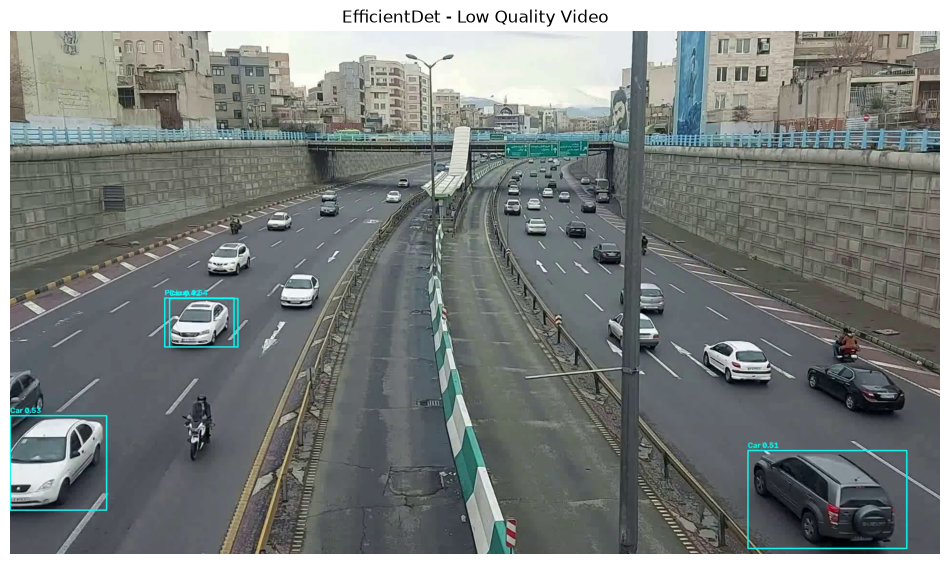

In [36]:
import matplotlib.pyplot as plt
import cv2

video_path = converted_videos["low"]

cap = cv2.VideoCapture(str(video_path))

ret, frame = cap.read()
cap.release()

if ret:
    plt.figure(figsize=(12, 7))
    plt.imshow(
        cv2.cvtColor(
            frame,
            cv2.COLOR_BGR2RGB
        )
    )
    plt.axis("off")
    plt.title("EfficientDet - Low Quality Video")
    plt.show()
else:
    print("Frame을 읽지 못했습니다.")

In [38]:
##YOLO 비교
#동일 Train / Valid 데이터
#동일 6 Classes
#30 Epoch
#입력 512
#같은 GPU

In [39]:
import json
import shutil
from collections import defaultdict

YOLO_ROOT = REPO_DIR / "datasets" / "my_car_yolo"

split_map = {
    "train": "train",
    "valid": "val",
    "test": "test"
}

for dst_split in split_map.values():
    (YOLO_ROOT / "images" / dst_split).mkdir(
        parents=True,
        exist_ok=True
    )

    (YOLO_ROOT / "labels" / dst_split).mkdir(
        parents=True,
        exist_ok=True
    )

In [40]:
def coco_to_yolo(
    coco_json,
    src_image_dir,
    dst_image_dir,
    dst_label_dir
):
    with open(coco_json, "r", encoding="utf-8") as f:
        data = json.load(f)

    images = {
        img["id"]: img
        for img in data["images"]
    }

    annotations = defaultdict(list)

    for ann in data["annotations"]:
        annotations[ann["image_id"]].append(ann)

    for image_id, image_info in images.items():

        file_name = image_info["file_name"]

        w_img = image_info["width"]
        h_img = image_info["height"]

        src_img = src_image_dir / file_name
        dst_img = dst_image_dir / Path(file_name).name

        shutil.copy2(src_img, dst_img)

        label_path = (
            dst_label_dir /
            (Path(file_name).stem + ".txt")
        )

        lines = []

        for ann in annotations[image_id]:

            x, y, w, h = ann["bbox"]

            x_center = (x + w / 2) / w_img
            y_center = (y + h / 2) / h_img

            w_norm = w / w_img
            h_norm = h / h_img

            # COCO category 1~6 -> YOLO 0~5
            class_id = ann["category_id"] - 1

            lines.append(
                f"{class_id} "
                f"{x_center:.6f} "
                f"{y_center:.6f} "
                f"{w_norm:.6f} "
                f"{h_norm:.6f}"
            )

        label_path.write_text(
            "\n".join(lines),
            encoding="utf-8"
        )

In [41]:
for src_split, dst_split in split_map.items():

    coco_to_yolo(
        coco_json=(
            ANNOT_DIR /
            f"instances_{src_split}.json"
        ),

        src_image_dir=(
            DST_ROOT /
            src_split
        ),

        dst_image_dir=(
            YOLO_ROOT /
            "images" /
            dst_split
        ),

        dst_label_dir=(
            YOLO_ROOT /
            "labels" /
            dst_split
        )
    )

print("YOLO dataset 변환 완료")

YOLO dataset 변환 완료


In [42]:
#YOLO용 data.yaml 생성
import yaml

YOLO_YAML = YOLO_ROOT / "data.yaml"

yolo_config = {
    "path": str(YOLO_ROOT),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": obj_list
}

with open(
    YOLO_YAML,
    "w",
    encoding="utf-8"
) as f:
    yaml.safe_dump(
        yolo_config,
        f,
        sort_keys=False,
        allow_unicode=True
    )

print(YOLO_YAML)

with open(YOLO_YAML, "r", encoding="utf-8") as f:
    print(f.read())

C:\Users\USER\Desktop\ERICA_X_MODULABS_CV\05_EfficientDet\Yet-Another-EfficientDet-Pytorch\datasets\my_car_yolo\data.yaml
path: C:\Users\USER\Desktop\ERICA_X_MODULABS_CV\05_EfficientDet\Yet-Another-EfficientDet-Pytorch\datasets\my_car_yolo
train: images/train
val: images/val
test: images/test
names:
- cars
- Bus
- Car
- Motorcycle
- Pickup
- Truck



In [44]:
# YOLOv8n에서도 30Epoch로 학습
from ultralytics import YOLO

yolo_model = YOLO("yolov8n.pt")

yolo_train = yolo_model.train(
    data=str(YOLO_YAML),
    epochs=30,
    imgsz=512,
    batch=4,
    device=0,
    workers=0,
    project=str(REPO_DIR / "yolo_runs"),
    name="vehicle_yolov8n_512",
    exist_ok=True
)

Ultralytics 8.4.155  Python-3.12.14 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\USER\Desktop\ERICA_X_MODULABS_CV\05_EfficientDet\Yet-Another-EfficientDet-Pytorch\datasets\my_car_yolo\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, 

In [45]:
#YOLO validation mAP 평가
YOLO_BEST = (
    REPO_DIR /
    "yolo_runs" /
    "vehicle_yolov8n_512" /
    "weights" /
    "best.pt"
)

best_yolo = YOLO(str(YOLO_BEST))

yolo_metrics = best_yolo.val(
    data=str(YOLO_YAML),
    imgsz=512,
    device=0,
    workers=0
)

print(
    "YOLO mAP@0.5:0.95:",
    yolo_metrics.box.map
)

print(
    "YOLO mAP@0.5:",
    yolo_metrics.box.map50
)

print(
    "YOLO mAP@0.75:",
    yolo_metrics.box.map75
)

Ultralytics 8.4.155  Python-3.12.14 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
Model summary (fused): 72 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.20.0 ms, read: 108.950.0 MB/s, size: 51.3 KB)
val: Scanning C:\Users\USER\Desktop\ERICA_X_MODULABS_CV\05_EfficientDet\Yet-Another-EfficientDet-Pytorch\datasets\my_car_yolo\labels\val.cache... 28 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 28/28  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.2it/s 1.6s3.1s
                   all         28        563      0.607      0.428      0.446      0.286
                   Bus          6          6      0.636      0.167      0.165      0.149
                   Car         23        398      0.694      0.673      0.698      0.453
            Motorcycle         18         92       0.74      0.526      0.548      0.273
                Pickup         22  

In [46]:
print(coco_eval.stats[0])
print(coco_eval.stats[1])
print(coco_eval.stats[2])

0.12326505090899234
0.25154066587696217
0.08169373008917


In [47]:
# YOLO 영상 평가 함수
def run_yolo_video(
    video_path,
    output_path,
    model,
    imgsz=512,
    conf=0.4,
    iou=0.2
):
    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        raise RuntimeError(
            f"영상 열기 실패: {video_path}"
        )

    source_fps = cap.get(cv2.CAP_PROP_FPS)

    width = int(
        cap.get(cv2.CAP_PROP_FRAME_WIDTH)
    )

    height = int(
        cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
    )

    writer = cv2.VideoWriter(
        str(output_path),
        cv2.VideoWriter_fourcc(*"mp4v"),
        source_fps,
        (width, height)
    )

    inference_times = []
    confidences = []
    detections_per_frame = []

    class_counter = Counter()

    frame_count = 0
    frames_with_detection = 0

    total_start = time.perf_counter()

    while True:
        ret, frame = cap.read()

        if not ret:
            break

        results = model.predict(
            source=frame,
            imgsz=imgsz,
            conf=conf,
            iou=iou,
            device=0,
            verbose=False
        )

        result = results[0]

        # Ultralytics 내부 측정 inference 시간
        inference_times.append(
            result.speed["inference"]
        )

        boxes = result.boxes

        n_det = len(boxes)
        detections_per_frame.append(n_det)

        if n_det > 0:
            frames_with_detection += 1

            cls_ids = (
                boxes.cls
                .detach()
                .cpu()
                .numpy()
                .astype(int)
            )

            scores = (
                boxes.conf
                .detach()
                .cpu()
                .numpy()
            )

            for cls_id, score in zip(
                cls_ids,
                scores
            ):
                label = model.names[cls_id]

                class_counter[label] += 1
                confidences.append(float(score))

        annotated = result.plot()

        writer.write(annotated)

        frame_count += 1

    cap.release()
    writer.release()

    total_elapsed = (
        time.perf_counter() -
        total_start
    )

    inference_times = np.array(
        inference_times
    )

    return {
        "Model": "YOLOv8n",
        "Video": video_path.stem,
        "Resolution": f"{width}x{height}",
        "Source_FPS": source_fps,
        "Frames": frame_count,

        "Inference_ms": float(
            np.mean(inference_times)
        ),

        "Inference_P95_ms": float(
            np.percentile(
                inference_times,
                95
            )
        ),

        "Model_FPS": float(
            1000 /
            np.mean(inference_times)
        ),

        "End_to_End_FPS": float(
            frame_count /
            total_elapsed
        ),

        "Avg_Detections_per_Frame": float(
            np.mean(
                detections_per_frame
            )
        ),

        "Frames_with_Detection_%": float(
            frames_with_detection /
            frame_count *
            100
        ),

        "Avg_Confidence": (
            float(
                np.mean(confidences)
            )
            if confidences
            else 0
        ),

        "Class_Counts": dict(
            class_counter
        ),

        "Output": str(output_path)
    }

In [48]:
# YOLO도 두 영상 모두 실행
yolo_results = []

for quality, video_path in VIDEO_PATHS.items():

    output_path = (
        OUTPUT_DIR /
        f"yolov8_{quality.lower()}.mp4"
    )

    print(f"\n===== YOLOv8 {quality} 시작 =====")

    result = run_yolo_video(
        video_path=video_path,
        output_path=output_path,
        model=best_yolo,
        imgsz=512,
        conf=0.4,
        iou=0.2
    )

    yolo_results.append(result)

    print("완료:", output_path)


===== YOLOv8 Low 시작 =====
완료: C:\Users\USER\Desktop\ERICA_X_MODULABS_CV\05_EfficientDet\Yet-Another-EfficientDet-Pytorch\video_results\yolov8_low.mp4

===== YOLOv8 High 시작 =====
완료: C:\Users\USER\Desktop\ERICA_X_MODULABS_CV\05_EfficientDet\Yet-Another-EfficientDet-Pytorch\video_results\yolov8_high.mp4


In [50]:
print("EfficientDet 결과 개수:", len(efficientdet_results))
print("YOLO 결과 개수:", len(yolo_results))

EfficientDet 결과 개수: 2
YOLO 결과 개수: 2


In [52]:
%pip install pandas

   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ------------------ --------------------- 4.5/9.7 MB 24.5 MB/s eta 0:00:01
   ---------------------------------------- 9.7/9.7 MB 27.4 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [53]:
import pandas as pd

print("pandas version:", pd.__version__)

pandas version: 3.0.6


In [55]:
import pandas as pd
from IPython.display import display

# EfficientDet / YOLO 결과를 DataFrame으로 변환
eff_df = pd.DataFrame(efficientdet_results)
yolo_df = pd.DataFrame(yolo_results)

# 두 결과 합치기
comparison_df = pd.concat(
    [eff_df, yolo_df],
    ignore_index=True
)

# 비교할 항목
columns_to_show = [
    "Model",
    "Video",
    "Resolution",
    "Inference_ms",
    "Inference_P95_ms",
    "Model_FPS",
    "End_to_End_FPS",
    "Avg_Detections_per_Frame",
    "Frames_with_Detection_%",
    "Avg_Confidence"
]

# 필요한 열만 선택
comparison_view = comparison_df.loc[:, columns_to_show].copy()

# 숫자 보기 좋게 반올림
numeric_cols = [
    "Inference_ms",
    "Inference_P95_ms",
    "Model_FPS",
    "End_to_End_FPS",
    "Avg_Detections_per_Frame",
    "Frames_with_Detection_%",
    "Avg_Confidence"
]

comparison_view.loc[:, numeric_cols] = (
    comparison_view.loc[:, numeric_cols].round(2)
)

# 표 출력
display(comparison_view)

,Model,Video,Resolution,Inference_ms,Inference_P95_ms,Model_FPS,End_to_End_FPS,Avg_Detections_per_Frame,Frames_with_Detection_%,Avg_Confidence
0,EfficientDet-D0,SampleVideo_LowQuality,1920x1080,155.63,304.14,6.43,1.99,2.06,89.91,0.50
1,EfficientDet-D0,Sample_Video_HighQuality,1920x1080,141.50,283.64,7.07,2.16,2.04,88.41,0.50
2,YOLOv8n,SampleVideo_LowQuality,1920x1080,30.36,73.34,32.93,9.74,12.14,100.00,0.67
3,YOLOv8n,Sample_Video_HighQuality,1920x1080,39.16,94.70,25.53,7.58,12.17,100.00,0.67


# EfficientDet-D0와 YOLOv8n 비교

EfficientDet의 결과만 확인하는 것보다 이전 실습에서 사용했던 YOLOv8n을 같은 영상과 같은 PC 환경에서 실행해보면 실제 사용 시 차이를 더 쉽게 이해할 수 있을 것 같아 추가 비교를 진행했습니다.

두 모델에 Low Quality와 High Quality 영상을 동일하게 입력하고 평균 Inference Time, P95 Latency, Model FPS, End-to-End FPS를 비교했습니다.

다만 두 모델의 학습 데이터와 클래스 구성이 완전히 동일한 것은 아니기 때문에 탐지 개수나 Confidence만으로 정확도의 우열을 판단하지 않고 이번 비교에서는 처리속도를 중심으로 확인했습니다.


In [ ]:
import pandas as pd
from pathlib import Path

video_results_manual = [
    {
        'Model': 'EfficientDet-D0',
        'Video': 'LowQuality',
        'Inference_ms': 155.63,
        'Inference_P95_ms': 304.14,
        'Model_FPS': 6.43,
        'End_to_End_FPS': 1.99
    },
    {
        'Model': 'EfficientDet-D0',
        'Video': 'HighQuality',
        'Inference_ms': 141.50,
        'Inference_P95_ms': 283.64,
        'Model_FPS': 7.07,
        'End_to_End_FPS': 2.16
    },
    {
        'Model': 'YOLOv8n',
        'Video': 'LowQuality',
        'Inference_ms': 30.36,
        'Inference_P95_ms': 73.34,
        'Model_FPS': 32.93,
        'End_to_End_FPS': 9.74
    },
    {
        'Model': 'YOLOv8n',
        'Video': 'HighQuality',
        'Inference_ms': 39.16,
        'Inference_P95_ms': 94.70,
        'Model_FPS': 25.53,
        'End_to_End_FPS': 7.58
    }
]

video_df = pd.DataFrame(
    video_results_manual
)

video_df['Pipeline_Efficiency_%'] = (
    video_df['End_to_End_FPS']
    / video_df['Model_FPS']
    * 100
)

video_df['P95_to_Mean_Ratio'] = (
    video_df['Inference_P95_ms']
    / video_df['Inference_ms']
)

display(
    video_df.round(2)
)


summary_rows = []

for video in [
    'LowQuality',
    'HighQuality'
]:

    sub = video_df[
        video_df['Video'] == video
    ]

    eff = sub[
        sub['Model'] == 'EfficientDet-D0'
    ].iloc[0]

    yolo = sub[
        sub['Model'] == 'YOLOv8n'
    ].iloc[0]

    summary_rows.append(
        {
            'Video': video,
            'YOLO_Model_FPS_Speedup': (
                yolo['Model_FPS']
                / eff['Model_FPS']
            ),
            'YOLO_E2E_FPS_Speedup': (
                yolo['End_to_End_FPS']
                / eff['End_to_End_FPS']
            ),
            'EfficientDet_Pipeline_Efficiency_%': (
                eff['Pipeline_Efficiency_%']
            ),
            'YOLO_Pipeline_Efficiency_%': (
                yolo['Pipeline_Efficiency_%']
            )
        }
    )


summary_df = pd.DataFrame(
    summary_rows
)

print('\n[추가 분석]')

display(
    summary_df.round(2)
)


ANALYSIS_DIR = (
    Path.home()
    / 'Desktop'
    / 'ERICA_X_MODULABS_CV'
    / '05_EfficientDet'
    / 'analysis_outputs'
)

ANALYSIS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

video_df.to_csv(
    ANALYSIS_DIR
    / 'video_model_comparison.csv',
    index=False,
    encoding='utf-8-sig'
)

summary_df.to_csv(
    ANALYSIS_DIR
    / 'video_speed_summary.csv',
    index=False,
    encoding='utf-8-sig'
)

print(
    '분석 결과 저장 완료:',
    ANALYSIS_DIR
)


## 영상 비교 결과에서 확인한 점

현재 측정 결과에서는 두 영상 모두 YOLOv8n이 EfficientDet-D0보다 더 높은 Model FPS와 End-to-End FPS를 보였습니다.

Low Quality 영상에서 EfficientDet-D0의 Model FPS는 약 6.43, YOLOv8n은 약 32.93이었으며 End-to-End FPS는 각각 약 1.99와 9.74였습니다.

High Quality 영상에서도 EfficientDet-D0는 약 7.07 Model FPS, YOLOv8n은 약 25.53 Model FPS로 나타났습니다.

수업에서 EfficientDet은 연산량과 정확도의 균형을 고려한 모델이라고 배웠지만 실제 실행속도는 모델 구조뿐 아니라 구현 방식, Framework, GPU 최적화와 현재 하드웨어 환경에도 영향을 받을 수 있다는 점을 확인했습니다.


## Model FPS와 End-to-End FPS 차이에 대한 생각

처음에는 Model FPS가 실제 영상을 처리할 수 있는 속도와 거의 같을 것이라고 생각했습니다.

하지만 두 모델 모두 End-to-End FPS가 Model FPS보다 크게 낮게 나타났습니다.

모델 추론 이외에도 영상을 읽고 Frame을 전처리하고 Bounding Box를 후처리하고 결과 영상을 생성하거나 저장하는 과정이 추가되기 때문이라고 생각했습니다.

따라서 실제 제조 영상 시스템에서 실시간 처리 가능 여부를 판단할 때는 모델의 FPS만 보는 것보다 전체 Pipeline을 포함한 End-to-End FPS를 확인하는 것이 중요하다고 느꼈습니다.


In [ ]:
# 동일한 영상 조건에서 YOLOv8n이 EfficientDet-D0보다 약 3.5~5배 높은 처리 속도를 보였음
# EfficientDet은 End-to-End 기준 약 2 FPS, YOLOv8n은 약 8~10 FPS 수준이었음
# YOLOv8n이 더 많은 객체를 지속적으로 탐지했지만 탐지 개수나 confidence만으로 정확도가 높다고 판단할 수는 없음
# 최종 성능 비교는 영상 처리 속도와 Validation mAP을 함께 확인하는 것이 필요함

# 실험의 한계

이번 EfficientDet과 YOLO 비교는 동일한 영상과 동일한 PC에서 진행했기 때문에 실제 처리속도의 차이를 확인하는 데는 의미가 있습니다.

하지만 두 모델이 완전히 동일한 학습 데이터와 클래스 조건으로 학습된 것은 아니기 때문에 평균 Confidence나 한 Frame에서 탐지한 객체 수를 이용해 정확도를 직접 비교하는 것은 어렵습니다.

YOLO가 더 많은 객체를 탐지했다고 해서 바로 정확도가 더 높다고 판단할 수는 없습니다.

두 모델의 정확도를 공정하게 비교하려면 동일한 Train Dataset으로 학습하고 동일한 Ground Truth를 이용해 mAP, Precision, Recall 등을 평가해야 한다고 생각했습니다.

또 Low Quality와 High Quality 영상에서 속도 차이가 나타났지만 이번 두 영상만으로 영상 품질 자체가 속도 차이의 원인이라고 단정하기도 어렵습니다.

영상의 내용, 객체 수, 압축 방식, GPU 상태 등 다른 요인도 영향을 줄 수 있기 때문입니다.


# KPT 회고

### Keep

교안의 이미지 추론에서 끝내지 않고 실제 영상을 이용해 모델이 어느 정도 속도로 동작하는지 직접 확인한 과정이 도움이 되었습니다.

또 Model FPS만 보는 것이 아니라 P95 Latency와 End-to-End FPS까지 같이 측정하면서 실제 영상 시스템의 처리속도를 조금 더 구체적으로 확인할 수 있었습니다.

### Problem

EfficientDet은 YOLO보다 직접 설정해야 하는 부분이 많았고 오픈소스 Repository의 코드 구조와 COCO Dataset 형식을 이해하는 과정에서 시간이 많이 필요했습니다.

또 처음에는 탐지 개수와 Confidence를 보고 두 모델의 정확도를 바로 비교하려고 했지만 학습 데이터와 클래스 조건이 다르면 공정한 정확도 비교가 어렵다는 점을 알게 되었습니다.

### Try

다음에는 EfficientDet과 YOLO를 동일한 Dataset과 클래스 조건으로 학습한 뒤 mAP와 FPS를 함께 비교해보고 싶습니다.

또 EfficientDet-D0뿐 아니라 D1처럼 Compound Scale을 변경했을 때 정확도와 처리속도가 어떻게 달라지는지도 확인해보고 싶습니다.

### Action After Review

앞으로 객체 탐지 모델을 비교할 때 모델 자체의 Inference Time뿐 아니라 End-to-End FPS와 P95 Latency도 같이 확인하려고 합니다.

또 서로 다른 모델의 성능을 비교할 때는 학습 데이터와 평가 조건이 동일한지 먼저 확인하고 결과를 해석하려고 합니다.


# 참고 자료

수업자료 `EfficientDet 기반 제조 영상 분석 최적화`를 기본 실습 자료로 사용했습니다.

EfficientDet 구현은 `Yet-Another-EfficientDet-Pytorch` 오픈소스 Repository를 활용했습니다.

프로젝트에서는 기본 코드를 그대로 실행하는 것에서 끝내지 않고 데이터셋 특성 분석, 데이터 맞춤 전처리 값과 Anchor 설정, 영상 처리 성능 측정, YOLOv8n 비교를 추가로 진행했습니다.
